In [78]:
import os
import sys
import json
import numpy as np
sys.path.append("../")
from modules.utils import(get_video_metadata, get_cropped_video_indices, load_splits_cropped, ALIGN_DIR)
from scipy.spatial.distance import pdist

In [ ]:
metadata_files = get_video_metadata("/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align")
LANDMARKS_DIR = "/Users/christina/code/RockPaperScissors_backup/my_rps_dataset/features_img/features_coords"

features_per_class = {"rock": [], "paper": [], "scissors": []}

for meta_file in metadata_files:
    with open(meta_file, "r") as f:
        data = json.load(f)
    start, onset, end, _ = get_cropped_video_indices(data)

    vid_name = meta_file.split('/')[-2]
    landmarks_file = os.path.join(LANDMARKS_DIR, f"{vid_name}_landmarks.npz")
    landmarks_data = np.load(landmarks_file, allow_pickle=True)
    landmarks = landmarks_data["landmarks"][start:end+1]
    print(f"Number of NaN frames in {vid_name}: {[np.isnan(landmarks[i]).all() for i in range(landmarks.shape[0])].count(True)}")
    label = data.get("label")
    features_per_class[label].append((landmarks.reshape(-1, 63), vid_name))


paper: 11 image files
['/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_49/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_38/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_36/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_31/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_37/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_45/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_20/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_35/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_50/metadata.json', '/Users/christina/code/RockPaper

(10, 13, 63)


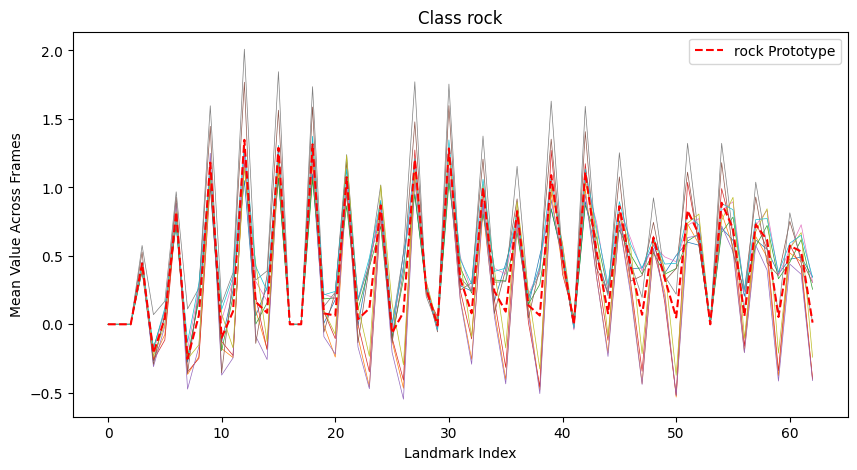

Prototype sample for class rock: rock_47
(10, 13, 63)


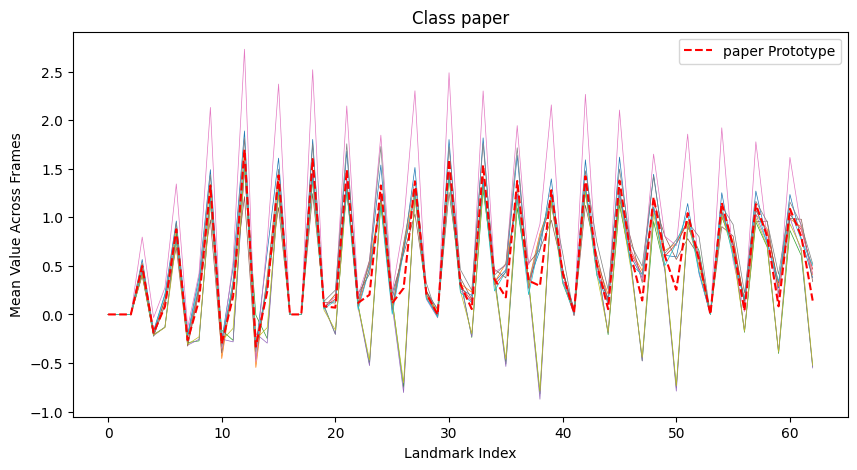

Prototype sample for class paper: paper_31
(10, 13, 63)


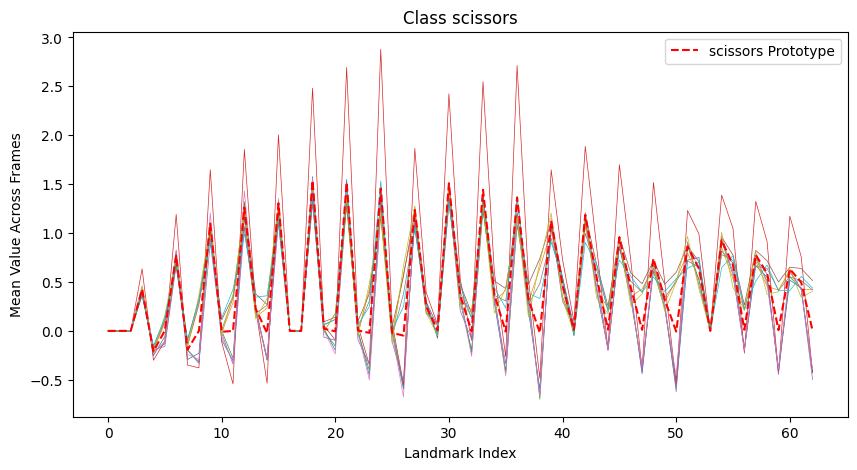

Prototype sample for class scissors: scissors_32


In [97]:
import matplotlib.pyplot as plt

def dist_from_prototype(prototype , sample):  
    d = np.linalg.norm(prototype - sample)
    return d
    
for gesture_class in ["rock", "paper", "scissors"]:
    # all_features = np.stack(features_per_class[gesture_class])
    all_features = np.stack([features_per_class[gesture_class][i][0] for i in range(len(features_per_class[gesture_class]))])
    N_CLASS_SAMPLES = all_features.shape[0]
    print(all_features.shape)

    avg_features_per_sample = np.apply_along_axis(np.nanmean, 1, all_features)
    avg_features_prototype = avg_features_per_sample.mean(axis=0)
    avg_features_per_sample.shape, avg_features_prototype.shape

    plt.figure(figsize=(10, 5))
    plt.title(f"Class {gesture_class}")
    for i in range(avg_features_per_sample.shape[0]):
        plt.plot(avg_features_per_sample[i], alpha=1, linewidth=0.5)
    plt.plot(avg_features_prototype, label=f"{gesture_class} Prototype", linestyle="--", color='red')
    plt.xlabel("Landmark Index")
    plt.ylabel("Mean Value Across Frames")
    plt.legend()
    plt.show()
    # Find min distance and return index of closest sample to prototype
    distances = np.apply_along_axis(dist_from_prototype, 1, avg_features_per_sample, avg_features_prototype)
    prototype_sample_idx = np.argmin(distances).item()
    print(f"Prototype sample for class {gesture_class}: {features_per_class[gesture_class][prototype_sample_idx][1]}")